# ECG/Resp Inspection
Processes ECG data (from files or from ICE parameters in the TWIX file) and displays time-domain plots with optionally detected events (R-peaks). Also plots respiratory signals and detects peaks/troughs for respiration.

### Loading packages and data

In [4]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import utils.data_ingestion as di
import utils.ecg_resp as ecg_resp
import scipy.signal as signal
# %matplotlib widget

def load_config(config_file="config.yaml"):
    """
    Load configuration from a YAML file.

    Parameters
    ----------
    config_file : str
        Path to the YAML configuration file.

    Returns
    -------
    dict
        Parsed configuration.
    """
    with open(config_file, "r") as f:
        return yaml.safe_load(f)

# Read config
config = load_config()

# Paths and optional file references
twix_file = config["data"]["twix_file"]
dicom_folder = config["data"]["dicom_folder"]
ecg_files = config["data"].get("ecg_files", None)
event_file = config["data"].get("event_file", None)
resp_file = config["data"].get("resp_file", None)
ecg_columns = config["data"].get("ecg_columns", None)
resp_column = config["data"].get("resp_column", None)
full_kspace_shape = config["data"]["full_kspace_shape"] # [n_frames, extended_pe_lines, n_coils, readout]
ref_scan = config['data']['ref_scan']

# Read TWIX, extract raw k-space, and derive sampling frequency
scans = di.read_twix_file(twix_file, include_scans=[-1], parse_pmu=False)

Software version: VD/VE (!?)

Scan  1


100%|██████████| 360M/360M [00:00<00:00, 1.15GB/s]

Read 1 scans from new_DATA/raw/meas_MID00056_FID00686_lax_Cine_rt_150meas_gre_75%FOV.dat


### Extracting and analyzing ECG

In [5]:
first_time = None
last_time = None
count = 0
for (i,mdb) in enumerate(scans[-1]['mdb']):
    if mdb.is_image_scan() or (ref_scan and mdb.is_flag_set("PATREFSCAN")):
        count += 1
        last_time = mdb.mdh.TimeStamp
        if first_time is None:
            first_time = mdb.mdh.TimeStamp

# print("First time: ", first_time)
# print("Last time: ", last_time)
# print("Time difference: ", (last_time - first_time) * 2.5e-3, "s")
# Get the sampling frequency
sampling_frequency = count / ((last_time - first_time) * 2.5e-3)
# print("Sampling frequency: ", sampling_frequency, "Hz")
# print("TR: ", 1/sampling_frequency * 1e3, "ms")

In [6]:
kspace = di.extract_image_data(scans[-1], full_kspace_shape=full_kspace_shape, ref_scan=ref_scan)

n_frames = full_kspace_shape[0]
# framerate, frametime = di.get_dicom_framerate(dicom_folder)
n_phase_encodes_per_frame = np.count_nonzero(~np.all(kspace == 0, axis=(0, 2, 3)))
# fs = framerate * n_phase_encodes_per_frame  # ECG / respiration sampling freq
# fs = 1 / (scans[-1]['hdr']['Phoenix']['alTR'][0] * 1e-6)
fs = sampling_frequency
print("Sampling frequency: ", fs)
print("TR: ", 1 / fs * 1e3, "ms")

# Load ECG data either from external files or from the ICE parameters
if ecg_files:
    # Concatenate multi-file ECG data channel-wise
    ecg_data = []
    for ecg_file in ecg_files:
        raw_ecg = np.loadtxt(ecg_file, skiprows=1, usecols=1)
        ecg_data.append(signal.resample(raw_ecg, kspace.shape[0]))
    ecg_data = np.vstack(ecg_data).T
else:
    ecg_data = di.extract_iceparam_data(scans, segment_index=0, columns=np.s_[int(ecg_columns.split(":")[0]):int(ecg_columns.split(":")[1])], ref_scan=ref_scan)
    # Force 2D shape
    if ecg_data.ndim == 1:
        ecg_data = ecg_data.reshape(-1, 1)

Extracted image data shape: (150, 96, 20, 256)
Sampling frequency:  216.21621621621622
TR:  4.625 ms
Extracted ICE parameter data shape: (9000, 3)


In [7]:
# Example (commented) R-peak detection
r_peaks_list = ecg_resp.detect_r_peaks(ecg_data, fs)
hr = ecg_resp.compute_average_heart_rate(r_peaks_list, fs)
print(f"Average heart rate: {hr:.2f} BPM")

# If event_file is present, interpret it as R-peak triggers or some other event
if event_file:
    resampled_length = kspace.shape[0]
    raw_events = np.loadtxt(event_file, skiprows=1, usecols=1)
    # Normalize events so that non-zero remain as spikes
    raw_events = raw_events - np.min(raw_events)
    raw_length = len(raw_events)

    # Create empty, then place spikes based on global fraction
    resampled_events = np.zeros(resampled_length)
    raw_spike_indices = np.nonzero(raw_events)[0]
    resampled_spike_indices = np.round(
        raw_spike_indices / (raw_length - 1) * (resampled_length - 1)
    ).astype(int)

    for (raw_idx, resampled_idx) in zip(raw_spike_indices, resampled_spike_indices):
        resampled_events[resampled_idx] = raw_events[raw_idx]
else:
    resampled_events = None

Average heart rate: 80.43 BPM


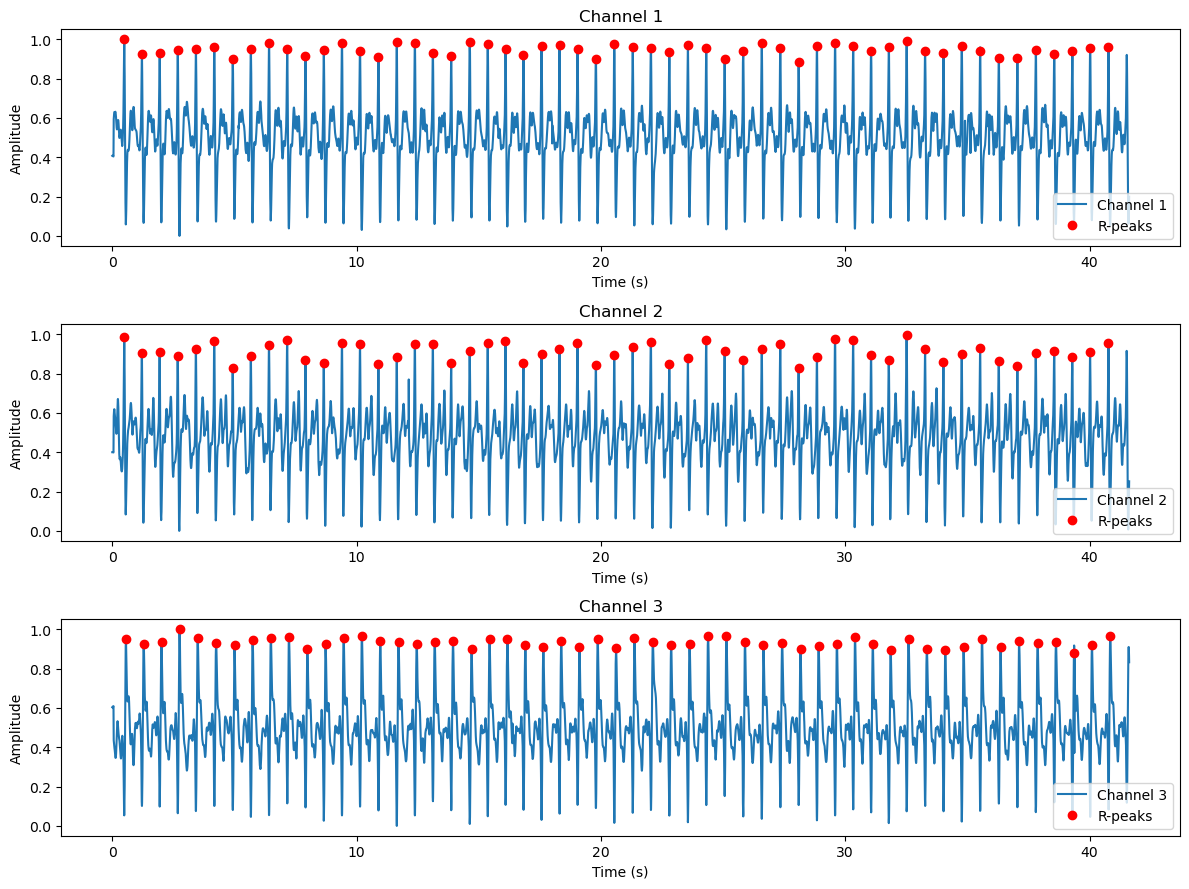

In [8]:
# Normalize ECG
ecg_data = (ecg_data - np.min(ecg_data, axis=0)) / (
    np.ptp(ecg_data, axis=0) + 1e-9
)

# Plot ECG with optional event spikes as vertical lines
# ecg_resp.plot_ecg_signals(ecg_data, fs, spike_indices=np.nonzero(resampled_events)[0] if resampled_events is not None else None, mode="separate")
ecg_resp.plot_ecg_signals(ecg_data, fs, r_peaks_list=r_peaks_list, mode="separate")

### Extracting and analyzing resp

Extracted ICE parameter data shape: (9000,)


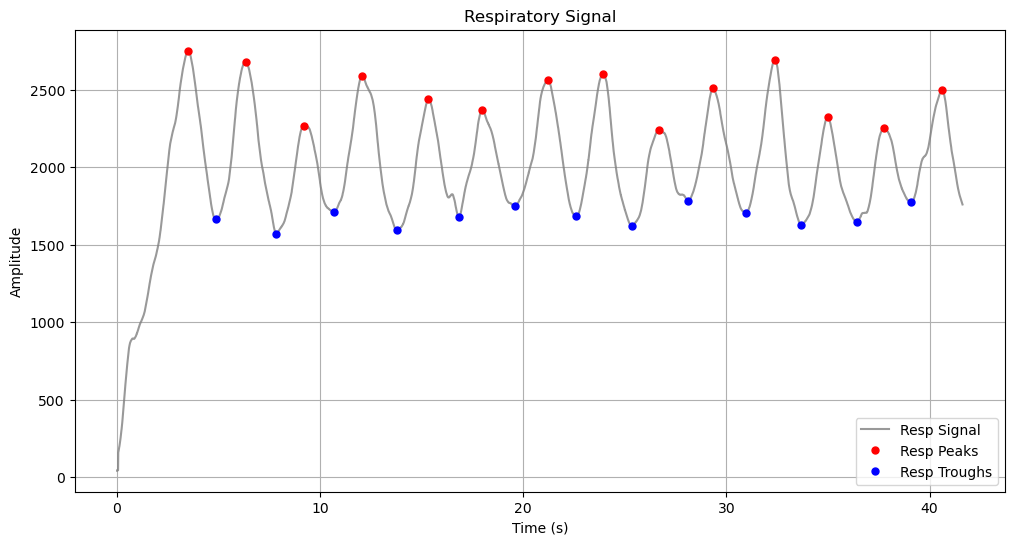

In [20]:
# If a respiratory file is present, load and detect peaks/troughs
if resp_file:
    resp_data = np.loadtxt(resp_file, skiprows=1, usecols=1)
    # Resample to match the total number of k-space time points
    resp_data = signal.resample(resp_data, kspace.shape[0])[:, np.newaxis]
else:
    resp_data = di.extract_iceparam_data(scans, segment_index=0, columns=np.s_[int(resp_column)], ref_scan=ref_scan)
    # Force 2D shape
    if resp_data.ndim == 1:
        resp_data = resp_data.reshape(-1, 1)

resp_peaks = ecg_resp.detect_resp_peaks(resp_data, fs, method='scipy', height=0.6, prominence=0.15)
resp_troughs = ecg_resp.detect_resp_peaks(-resp_data, fs, method='scipy', height=0.2, prominence=0.15)

# Plot
ecg_resp.plot_resp_signal(resp_data, fs, resp_peaks=resp_peaks, resp_troughs=resp_troughs)

# (EXPERIMENTAL) Real-Time Resp Peak/Trough Detection Improvement

In [ ]:
from tslearn.backend import instantiate_backend
from tslearn.utils import to_time_series
import numpy
from numba import njit

@njit()
def _njit_subsequence_path(acc_cost_mat, idx_path_end):
    r"""Compute the optimal path through an accumulated cost matrix given the
    endpoint of the sequence.

    Parameters
    ----------
    acc_cost_mat: array-like, shape=(sz1, sz2)
        Accumulated cost matrix comparing subsequence from a longer sequence.
    idx_path_end: int
        The end position of the matched subsequence in the longer sequence.

    Returns
    -------
    path: list of tuples of integer pairs
        Matching path represented as a list of index pairs. In each pair, the
        first index corresponds to `subseq` and the second one corresponds to
        `longseq`. The startpoint of the Path is :math:`P_0 = (0, ?)` and it
        ends at :math:`P_L = (len(subseq)-1, idx\_path\_end)`
    """
    sz1, sz2 = acc_cost_mat.shape
    path = [(sz1 - 1, idx_path_end)]
    while path[-1][0] != 0:
        i, j = path[-1]
        if i == 0:
            path.append((0, j - 1))
        elif j == 0:
            path.append((i - 1, 0))
        else:
            arr = numpy.array(
                [
                    acc_cost_mat[i - 1][j - 1],
                    acc_cost_mat[i - 1][j],
                    acc_cost_mat[i][j - 1],
                ]
            )
            argmin = numpy.argmin(arr)
            if argmin == 0:
                path.append((i - 1, j - 1))
            elif argmin == 1:
                path.append((i - 1, j))
            else:
                path.append((i, j - 1))
    return path[::-1]

@njit()
def _njit_local_squared_dist(x, y):
    """Compute the squared distance between two vectors.

    Parameters
    ----------
    x : array-like, shape=(d,)
        A vector.
    y : array-like, shape=(d,)
        Another vector.

    Returns
    -------
    dist : float
        Squared distance between x and y.
    """
    dist = 0.0
    for di in range(x.shape[0]):
        diff = x[di] - y[di]
        dist += diff * diff
    return dist

@njit()
def _njit_local_custom_dist(x, y, alpha=1.0):
    """Compute the distance between two vectors.

    Parameters
    ----------
    x : array-like, shape=(d,)
        A vector.
    y : array-like, shape=(d,)
        Another vector.

    Returns
    -------
    dist : float
        Squared distance between x and y.
    """
    dist = 0.0
    for di in range(x.shape[0]):
        diff = x[di] - y[di]
        dist += diff ** alpha
    return dist

@njit()
def _njit_subsequence_cost_matrix(subseq, longseq, warp_penalty=0.0, alpha=1.0):
    """Compute the accumulated cost matrix score between a subsequence and
    a reference time series.

    Parameters
    ----------
    subseq : array-like, shape=(sz1, d)
        Subsequence time series.
    longseq : array-like, shape=(sz2, d)
        Reference time series.

    Returns
    -------
    mat : array-like, shape=(sz1, sz2)
        Accumulated cost matrix.
    """
    l1 = subseq.shape[0]
    l2 = longseq.shape[0]
    cum_sum = numpy.full((l1 + 1, l2 + 1), numpy.inf)
    cum_sum[0, :] = 0.0

    for i in range(l1):
        for j in range(l2):
            d = _njit_local_custom_dist(subseq[i], longseq[j], alpha=alpha)
            diag = cum_sum[i, j]
            vert = cum_sum[i, j + 1] + warp_penalty
            hori = cum_sum[i + 1, j] + warp_penalty
            cum_sum[i + 1, j + 1] = d + min(diag, vert, hori)
    return cum_sum[1:, 1:]

def m_dtw_subsequence_path(subseq, longseq, be=None, warp_penalty=0.0, alpha=1.0):
    r"""Compute sub-sequence Dynamic Time Warping (DTW) similarity measure
    between a (possibly multidimensional) query and a long time series and
    return both the path and the similarity.

    DTW is computed as the Euclidean distance between aligned time series,
    i.e., if :math:`\pi` is the alignment path:

    .. math::

        DTW(X, Y) = \sqrt{\sum_{(i, j) \in \pi} \|X_{i} - Y_{j}\|^2}

    Compared to traditional DTW, here, border constraints on admissible paths
    :math:`\pi` are relaxed such that :math:`\pi_0 = (0, ?)` and
    :math:`\pi_L = (N-1, ?)` where :math:`L` is the length of the considered
    path and :math:`N` is the length of the subsequence time series.

    It is not required that both time series share the same size, but they must
    be the same dimension. This implementation finds the best matching starting
    and ending positions for `subseq` inside `longseq`.

    Parameters
    ----------
    subseq : array-like, shape=(sz1, d) or (sz1,)
        A query time series.
        If shape is (sz1,), the time series is assumed to be univariate.
    longseq : array-like, shape=(sz2, d) or (sz2,)
        A reference (supposed to be longer than `subseq`) time series.
        If shape is (sz2,), the time series is assumed to be univariate.
    be : Backend object or string or None
        Backend. If `be` is an instance of the class `NumPyBackend` or the string `"numpy"`,
        the NumPy backend is used.
        If `be` is an instance of the class `PyTorchBackend` or the string `"pytorch"`,
        the PyTorch backend is used.
        If `be` is `None`, the backend is determined by the input arrays.
        See our :ref:`dedicated user-guide page <backend>` for more information.

    Returns
    -------
    list of integer pairs
        Matching path represented as a list of index pairs. In each pair, the
        first index corresponds to `subseq` and the second one corresponds to
        `longseq`.
    float
        Similarity score
    """
    be = instantiate_backend(be, subseq, longseq)
    subseq = to_time_series(subseq, be=be)
    longseq = to_time_series(longseq, be=be)
    acc_cost_mat = _njit_subsequence_cost_matrix(subseq=subseq, longseq=longseq, warp_penalty=warp_penalty, alpha=alpha)
    global_optimal_match = be.argmin(acc_cost_mat[-1, :])
    path = _njit_subsequence_path(acc_cost_mat, global_optimal_match)
    return path, be.sqrt(acc_cost_mat[-1, :][global_optimal_match])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tslearn.metrics import dtw_subsequence_path
from tqdm import tqdm
import matplotlib.cm as cm
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# Assume resp_data is your (N, 1) ndarray:
resp_data = resp_data.flatten()

# Define two full respiratory cycles as the template
cycle1_start, cycle1_end = resp_peaks[0], resp_peaks[1]
cycle2_start, cycle2_end = resp_peaks[1], resp_peaks[2]

template = resp_data[cycle1_start:cycle2_end]  # Two full cycles
template = gaussian_filter1d(template, sigma=10)
template_norm = (template - np.min(template)) / (np.max(template) - np.min(template))

# Normalize the full respiratory signal
resp_data_norm = (resp_data - np.min(resp_data)) / (np.max(resp_data) - np.min(resp_data))

# Parameters
window_size = (cycle2_end - cycle1_start) // 2  # Length of one full cycle
stretch_factor = 1.0  # You can change this to apply horizontal stretch

# Store estimated phase at each time step
phases = np.full_like(resp_data_norm, np.nan, dtype=float)

# Loop through the signal in real-time fashion
for t in tqdm(range(window_size, len(resp_data_norm))):
    current_window = resp_data_norm[t - window_size + 1:t + 1]  # Most recent full cycle window
    current_window = gaussian_filter1d(current_window, sigma=10)

    # Subsequence DTW: match recent window to the 2-cycle template
    path, _ = m_dtw_subsequence_path(current_window, template_norm, warp_penalty=1, alpha=10)
    window_indices, template_indices = zip(*path)

    # Find where the last sample of the current window (i.e., t) aligns in the template
    if window_size - 1 in window_indices:
        idx_in_path = window_indices.index(window_size - 1)
        matched_template_index = template_indices[idx_in_path]

        # --- Phase calculation for two‑cycle template ---
        cycle_len = cycle1_end - cycle1_start  # assume both cycles equal length
        if matched_template_index < cycle_len:
            # first cycle
            phase_percent = matched_template_index / cycle_len
        else:
            # second cycle
            phase_percent = (matched_template_index - cycle_len) / cycle_len
        phases[t] = phase_percent

    # Debug plot every 500 samples
    if t % 500 == 0:
        # DTW alignment lines with gradient coloring and horizontal centering/stretching
        offset = 1.2  # vertical offset for template
        plt.figure(figsize=(12, 4))

        # Apply stretch and center current window horizontally under matched segment
        template_center = int(np.median(template_indices[::25]))
        window_center = int(np.median(window_indices[::25]))
        shift = template_center - window_center

        x_window = np.arange(len(current_window)) * stretch_factor + shift

        # Interpolate current window if stretched
        if stretch_factor != 1.0:
            f_interp = interp1d(np.linspace(0, len(current_window) - 1, len(current_window)), current_window, kind='linear')
            x_stretched = np.linspace(0, len(current_window) - 1, int(len(current_window) * stretch_factor))
            current_window = f_interp(x_stretched)
            x_window = np.arange(len(current_window)) + shift

        num_lines = len(window_indices[::25])
        colors = cm.viridis(np.linspace(0, 1, num_lines))
        for i, (wi, ti) in enumerate(zip(window_indices[::25], template_indices[::25])):
            if wi < len(x_window) and ti < len(template_norm):
                plt.plot([ti, x_window[wi]], [template_norm[ti] + offset, current_window[wi]], color=colors[i], alpha=0.6)

        plt.plot(template_norm + offset, label='Template (2 Cycles) + offset')
        plt.plot(x_window, current_window, label='Current Window (Centered & Stretched)')
        plt.xlabel('Index')
        plt.ylabel('Normalized Value')
        plt.legend()
        plt.title(f'DTW Alignment Overlay at t = {t}')
        plt.tight_layout()
        plt.show()

# Final Plot
plt.figure(figsize=(12, 4))
plt.plot(resp_data_norm, label='Normalized Respiratory Signal')
plt.plot(phases, label='Estimated Respiratory Phase (%)', linestyle='--')
plt.xlabel('Time (samples)')
plt.ylabel('Normalized Amplitude / Phase')
plt.legend()
plt.title('Estimated Respiratory Phase via Subsequence DTW (Two-Cycle Template)')
plt.tight_layout()
plt.show()

In [ ]:
# t = np.arange(N)/fs
# plt.figure(figsize=(10,5))

# # Plot the offline reference fraction (unchanged)
# plt.plot(t, actual_fraction, label='Actual Fraction (Offline)', linewidth=2, color='black')

# # Instead of a single line for predicted_fraction, we segment it by predicted_phase.
# # We'll use green for inhalation (True), blue for exhalation (False), and gray if unknown.
# start_idx = 0
# for i in range(1, N):
#     # If the phase indicator changes, plot the segment from start_idx to i-1.
#     if predicted_phase[i] != predicted_phase[i-1]:
#         seg_t = t[start_idx:i]
#         seg_y = predicted_fraction[start_idx:i]
#         if predicted_phase[i-1] is True:
#             color = 'green'      # inhalation
#         elif predicted_phase[i-1] is False:
#             color = 'blue'       # exhalation
#         else:
#             color = 'gray'
#         plt.plot(seg_t, seg_y, '-', color=color, linewidth=2)
#         start_idx = i
# # Plot the last segment
# if start_idx < N:
#     seg_t = t[start_idx:]
#     seg_y = predicted_fraction[start_idx:]
#     if predicted_phase[-1] is True:
#         color = 'green'
#     elif predicted_phase[-1] is False:
#         color = 'blue'
#     else:
#         color = 'gray'
#     plt.plot(seg_t, seg_y, '-', color=color, linewidth=2)

# # Optionally, add a vertical line at calibration end
# if calibration_end_idx is not None:
#     plt.axvline(calibration_end_idx/fs, color='r', linestyle=':', linewidth=2, label='Calibration End')

# # Normalize raw resp_signal to range 0-100
# raw_norm = (resp_signal - np.min(resp_signal)) / (np.ptp(resp_signal)) * 100.0
# plt.plot(t, raw_norm, label='Raw Signal (Normalized)', color='magenta', alpha=0.5)

# plt.title("Online Peak/Trough Detection, Fraction & Phase Indicator")
# plt.xlabel("Time (s)")
# plt.ylabel("Breath Cycle Fraction (%)")
# plt.grid(True)
# plt.legend(loc='upper left')
# plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from scipy import signal
import utils.ecg_resp as ecg_resp  # Existing utility module

def detect_resp_peaks_realtime(resp_data, fs, candidate_prominence=0.03, confirm_prominence=0.15, 
                               height=None, time_constant=0.2, 
                               candidate_left_threshold=0.15, 
                               confirmed_left_threshold=0.4, confirmed_right_threshold=0.15):
    """
    Detect respiratory peaks in a 1D signal in real time using a two-stage process with custom
    left/right prominence checks.
    
    For peaks:
      - Candidate peaks are first identified on an EMA-filtered version of the signal using a
        candidate prominence of 0.03. These candidates are then filtered by verifying that their
        left-side prominence (computed on the EMA-filtered signal) is at least candidate_left_threshold.
      - Confirmed (actual) peaks are then detected on the original normalized signal using a prominence 
        of 0.15. These peaks are verified by requiring that the left prominence is at least 
        confirmed_left_threshold and the right prominence is at least confirmed_right_threshold.
    
    For troughs:
      - Call this function on the inverted signal and set candidate_left_threshold and 
        confirmed_left_threshold as needed (e.g., 0.4 for candidate troughs and 0.4 for confirmed troughs,
        with confirmed_right_threshold remaining 0.15).
    
    Parameters
    ----------
    resp_data : np.ndarray
        Respiratory signal (shape: [n_samples] or [n_samples, 1]).
    fs : float
        Sampling frequency in Hz.
    candidate_prominence : float, optional
        Prominence threshold for candidate detection (default is 0.03).
    confirm_prominence : float, optional
        Prominence threshold for confirmed detection (default is 0.15).
    height : float, optional
        Minimum peak height. Only peaks above this value are considered.
    time_constant : float, optional
        Time constant (in seconds) for EMA smoothing.
    candidate_left_threshold : float, optional
        Minimum required left prominence for candidate peaks (only left side is checked).
    confirmed_left_threshold : float, optional
        Minimum required left prominence for confirmed peaks.
    confirmed_right_threshold : float, optional
        Minimum required right prominence for confirmed peaks.
    
    Returns
    -------
    tuple of np.ndarray
        candidate_peaks: Indices of candidate peaks (after left prominence check and adjustment).
        confirmed_peaks: Indices of confirmed peaks (after left/right prominence verification).
    """
    # Ensure the input is a 1D array.
    if resp_data.ndim > 1:
        resp_data = resp_data.flatten()
    
    # Normalize the original signal.
    norm_resp = (resp_data - np.min(resp_data)) / (np.ptp(resp_data) + 1e-9)
    
    # ---------------- EMA Filtering ----------------
    # Low-pass filter the signal using an Exponential Moving Average (EMA) to reduce noise.
    alpha = (1 / fs) / (time_constant + 1 / fs)  # Compute smoothing factor
    smoothed_resp = np.zeros_like(norm_resp)
    smoothed_resp[0] = norm_resp[0]
    for i in range(1, len(norm_resp)):
        smoothed_resp[i] = alpha * norm_resp[i] + (1 - alpha) * smoothed_resp[i - 1]
    
    # ---------------- Candidate Peak Detection ----------------
    # Identify candidate peaks on the EMA-smoothed signal using the candidate prominence.
    candidate_peaks, _ = signal.find_peaks(smoothed_resp, height=height, prominence=candidate_prominence)
    
    # Filter candidate peaks: only check left prominence on the smoothed signal.
    if candidate_peaks.size > 0:
        cand_proms, cand_left_bases, _ = signal.peak_prominences(smoothed_resp, candidate_peaks)
        candidate_left_proms = smoothed_resp[candidate_peaks] - smoothed_resp[cand_left_bases]
        valid_cand_mask = candidate_left_proms >= candidate_left_threshold
        candidate_peaks = candidate_peaks[valid_cand_mask]
    
    # "Fix" candidate peak positions: adjust to the highest point in the original normalized signal
    # within a window of time_constant seconds.
    window_size = int(time_constant * fs)
    candidate_peaks = np.array([
        np.argmax(norm_resp[max(0, peak - window_size):min(len(norm_resp), peak + window_size)]) 
        + max(0, peak - window_size)
        for peak in candidate_peaks
    ])
    
    # ---------------- Confirmed (Actual) Peak Detection ----------------
    # Detect confirmed peaks on the original normalized signal using the higher prominence threshold.
    confirmed_peaks, _ = signal.find_peaks(norm_resp, height=height, prominence=confirm_prominence)
    
    # Verify confirmed peaks by checking both left and right prominences.
    if confirmed_peaks.size > 0:
        conf_proms, conf_left_bases, conf_right_bases = signal.peak_prominences(norm_resp, confirmed_peaks)
        confirmed_left_proms = norm_resp[confirmed_peaks] - norm_resp[conf_left_bases]
        confirmed_right_proms = norm_resp[confirmed_peaks] - norm_resp[conf_right_bases]
        valid_conf_mask = (confirmed_left_proms >= confirmed_left_threshold) & \
                          (confirmed_right_proms >= confirmed_right_threshold)
        confirmed_peaks = confirmed_peaks[valid_conf_mask]
    
    return candidate_peaks, confirmed_peaks


# ---------------- Real-Time Animation Setup ----------------

# Assume resp_data and fs are already defined and loaded in a previous cell.
resp_signal = resp_data.flatten()
N = len(resp_signal)
time_array = np.arange(N) / fs  # Create time vector based on sampling frequency

# Parameters for candidate and confirmed detection.
peak_height = 0.6             # Minimum peak height for detection.
candidate_prominence = 0.03   # Candidate prominence threshold.
confirm_prominence = 0.15     # Confirmed (actual) prominence threshold.
min_time = 10                 # Minimum time (in seconds) before starting detection.
time_constant = 0.1           # Time constant for EMA smoothing (in seconds).

# Create the figure and initialize plot elements.
fig, ax = plt.subplots(figsize=(16, 8), dpi=40)

# Plot for the respiratory signal.
line, = ax.plot([], [], lw=2, color='gray', label='Resp Signal')

# Scatter plots for candidate and confirmed peaks.
candidate_peaks_scatter = ax.scatter([], [], color='orange', s=50, marker='x', label='Candidate Peaks')
confirmed_peaks_scatter = ax.scatter([], [], color='red', s=50, marker='o', label='Confirmed Peaks')

# Scatter plots for candidate and confirmed troughs.
candidate_troughs_scatter = ax.scatter([], [], color='cyan', s=50, marker='x', label='Candidate Troughs')
confirmed_troughs_scatter = ax.scatter([], [], color='blue', s=50, marker='o', label='Confirmed Troughs')

ax.set_xlabel("Time (s)")
ax.set_ylabel("Signal Amplitude")
ax.set_title("Real-Time Respiratory Signal with Two-Stage Detected Peaks/Troughs")
ax.legend()

# Set initial x and y limits.
ax.set_xlim(0, time_array[-1])
ymin, ymax = 0, 1
ax.set_ylim(ymin - 0.1 * np.abs(ymin), ymax + 0.1 * np.abs(ymax))

def init():
    """
    Initialize the plot elements for the animation.
    
    Returns
    -------
    tuple
        Initialized plot artists.
    """
    line.set_data([], [])
    candidate_peaks_scatter.set_offsets(np.empty((0, 2)))
    confirmed_peaks_scatter.set_offsets(np.empty((0, 2)))
    candidate_troughs_scatter.set_offsets(np.empty((0, 2)))
    confirmed_troughs_scatter.set_offsets(np.empty((0, 2)))
    return (line, candidate_peaks_scatter, confirmed_peaks_scatter,
            candidate_troughs_scatter, confirmed_troughs_scatter)

def update(frame_fraction):
    """
    Update function for each frame of the animation using the two-stage detection with custom
    left/right prominence thresholds.
    
    Parameters
    ----------
    frame_fraction : float
        Fraction (between 0 and 1) of the total signal length to display.
    
    Returns
    -------
    tuple
        Updated plot artists.
    """
    # Determine the current index based on frame_fraction.
    current_idx = int(frame_fraction * N)
    if current_idx < 2:
        current_idx = 2

    # Extract and normalize the current segment of the signal.
    current_signal = resp_signal[:current_idx]
    current_signal = (current_signal - np.min(current_signal)) / (np.ptp(current_signal) + 1e-9)
    current_time = time_array[:current_idx]
    
    # Start detection only if sufficient time has passed.
    if current_time[-1] > min_time:
        # For peaks: candidate detection with candidate_left_threshold=0.15; 
        # confirmed detection requires left>=0.4 and right>=0.15.
        candidate_peaks, confirmed_peaks = detect_resp_peaks_realtime(
            current_signal, fs, candidate_prominence=candidate_prominence,
            confirm_prominence=confirm_prominence, height=peak_height, time_constant=time_constant,
            candidate_left_threshold=0.15, confirmed_left_threshold=0.15, confirmed_right_threshold=0.4
        )
        # For troughs: process the inverted signal.
        # Candidate troughs: candidate_left_threshold=0.4 (only left check);
        # Confirmed troughs: require left>=0.4 and right>=0.15.
        candidate_troughs, confirmed_troughs = detect_resp_peaks_realtime(
            -current_signal, fs, candidate_prominence=candidate_prominence,
            confirm_prominence=confirm_prominence, height=peak_height, time_constant=time_constant,
            candidate_left_threshold=0.4, confirmed_left_threshold=0.4, confirmed_right_threshold=0.15
        )
    else:
        candidate_peaks = np.array([])
        confirmed_peaks = np.array([])
        candidate_troughs = np.array([])
        confirmed_troughs = np.array([])
    
    # Prepare coordinates for candidate peaks.
    if candidate_peaks.size > 0:
        candidate_peaks_times = current_time[candidate_peaks]
        candidate_peaks_values = current_signal[candidate_peaks]
        candidate_peaks_coords = np.column_stack((candidate_peaks_times, candidate_peaks_values))
    else:
        candidate_peaks_coords = np.empty((0, 2))
        
    # Prepare coordinates for confirmed peaks.
    if confirmed_peaks.size > 0:
        confirmed_peaks_times = current_time[confirmed_peaks]
        confirmed_peaks_values = current_signal[confirmed_peaks]
        confirmed_peaks_coords = np.column_stack((confirmed_peaks_times, confirmed_peaks_values))
    else:
        confirmed_peaks_coords = np.empty((0, 2))
    
    # Prepare coordinates for candidate troughs.
    if candidate_troughs.size > 0:
        candidate_troughs_times = current_time[candidate_troughs]
        candidate_troughs_values = current_signal[candidate_troughs]
        candidate_troughs_coords = np.column_stack((candidate_troughs_times, candidate_troughs_values))
    else:
        candidate_troughs_coords = np.empty((0, 2))
        
    # Prepare coordinates for confirmed troughs.
    if confirmed_troughs.size > 0:
        confirmed_troughs_times = current_time[confirmed_troughs]
        confirmed_troughs_values = current_signal[confirmed_troughs]
        confirmed_troughs_coords = np.column_stack((confirmed_troughs_times, confirmed_troughs_values))
    else:
        confirmed_troughs_coords = np.empty((0, 2))
    
    # Update the line plot and scatter markers.
    line.set_data(current_time, current_signal)
    candidate_peaks_scatter.set_offsets(candidate_peaks_coords)
    confirmed_peaks_scatter.set_offsets(confirmed_peaks_coords)
    candidate_troughs_scatter.set_offsets(candidate_troughs_coords)
    confirmed_troughs_scatter.set_offsets(confirmed_troughs_coords)
    
    # Update the x-axis limit to simulate real-time progress.
    ax.set_xlim(0, current_time[-1])
    
    return (line, candidate_peaks_scatter, confirmed_peaks_scatter,
            candidate_troughs_scatter, confirmed_troughs_scatter)

# Create the animation with 500 frames spanning the entire signal.
anim = FuncAnimation(fig, update, frames=np.linspace(0, 1, 500), init_func=init,
                     blit=True, interval=10)

# Display the animation in the notebook as jshtml.
display(HTML(anim.to_jshtml()))

# Save the animation as a GIF using the Pillow writer.
# anim.save('resp_animation.gif', writer='pillow', fps=30)

# (EXPERIMENTAL) Real-time ECG detection improvement

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy import signal
from tqdm import tqdm

# ---------------- Parameters ----------------
# Assume ecg_data is an Nx1 or NxM array with your ECG data and fs is defined.
calibration_time = 10.0      # seconds
calibration_samples = int(calibration_time * fs)

# Example bandpass filter (shown in your snippet, not explicitly used here)
b, a = signal.butter(4, [0.6, 1.5], btype='band', fs=fs)

# PCA pipeline: standardize, then take 1 principal component
scaler = StandardScaler()
pca = PCA(n_components=1)
pipe = make_pipeline(scaler, pca)

# Prepare output arrays
N = len(ecg_data)
time_array = np.arange(N) / fs
online_output = np.full(N, np.nan)  # To store the latest (inverted & normalized) PCA sample at each iteration

# ---------------- Real-time Simulation (Incremental PCA) ----------------
for i in tqdm(range(N)):
    if i < 3:
        continue

    # 2) Once calibration is done, take all data so far
    current_segment = ecg_data[: i + 1]  # shape: (i+1, ...)

    pca_result = pipe.fit_transform(current_segment)

    # Flatten to 1D and multiply by -1 BEFORE normalization.
    principal_component = pca_result.flatten()
    principal_component = -principal_component  # Invert the sign

    # Normalize based on min/max so far
    pc_min = np.min(principal_component)
    pc_ptp = np.ptp(principal_component) + 1e-9  # avoid division by zero
    normalized = (principal_component - pc_min) / pc_ptp

    # Store the latest sample in our output array
    online_output[i] = normalized[-1]

# -----------------------------------------------------------------------
# AFTER building the full "online_output", do a final pass:
#   (A) Detect "true" R-peaks in the raw ECG (first lead).
#   (B) For each true ECG peak, in a ±5% window of the cardiac cycle in the PCA signal,
#       find the absolute maximum (the "true" PCA peak) and record its height and left prominence.
#   (C) Set detection thresholds for the PCA candidates:
#           height_threshold = max(min(height_values) - 0.5*std(height_values), 0)
#           leftprom_threshold = max(min(left_prom_values) - 0.5*std(left_prom_values), 0)
#   (D) Run candidate detection on the PCA signal using these thresholds.
#   (E) Plot the raw ECG (normalized), true peaks, the PCA signal, candidate peaks,
#       the threshold lines, and the search windows.
# -----------------------------------------------------------------------

# Helper function for peak-to-peak ignoring NaNs.
def nanptp(arr, axis=None, out=None, keepdims=np._NoValue):
    return np.nanmax(arr, axis=axis, out=out, keepdims=keepdims) - \
           np.nanmin(arr, axis=axis, out=out, keepdims=keepdims)

# A) Detect true R-peaks in raw ECG (first lead)
raw_lead = ecg_data[:, 0]
true_peaks = list(ecg_resp.detect_r_peaks(raw_lead, fs)[0])
true_peaks.pop(63)
true_peaks.pop(52)
true_peaks.pop(50)
true_peaks.pop(36)
true_peaks.pop(25)
true_peaks.pop(23)
true_peaks.pop(9)
true_peaks = np.array(true_peaks)

# B) Map each true ECG peak to a PCA peak
# Use a window of ±5% of the average R–R interval.
pc_peak_values = []
pc_left_proms = []
search_windows = []  # To store the (start, end) indices for plotting

# To avoid issues with NaNs in online_output, fill them with the mean of valid values.
valid_mask = ~np.isnan(online_output)
if np.any(valid_mask):
    mean_val = np.mean(online_output[valid_mask])
    online_filled = np.copy(online_output)
    online_filled[~valid_mask] = mean_val
else:
    online_filled = online_output.copy()

if true_peaks.size > 1:
    rr_intervals = np.diff(true_peaks)
    if rr_intervals.size > 0:
        avg_rr = int(np.mean(rr_intervals))
        win = int(0.05 * avg_rr)
        if win < 1:
            win = 1

        for p in true_peaks:
            left_bound = max(p - win, 0)
            right_bound = min(p + win, N - 1)
            search_windows.append((left_bound, right_bound))
            
            segment = online_filled[left_bound : right_bound + 1]
            if len(segment) == 0:
                continue
            # Find the absolute maximum in this segment.
            local_idx_rel = np.argmax(segment)
            local_idx_abs = left_bound + local_idx_rel
            local_max_val = online_filled[local_idx_abs]
            pc_peak_values.append(local_max_val)
            
            # Compute left-side prominence for this local PCA peak.
            proms, left_bases, _ = signal.peak_prominences(online_filled, [local_idx_abs])
            if len(left_bases) > 0:
                left_prom_val = online_filled[local_idx_abs] - online_filled[left_bases[0]]
            else:
                left_prom_val = 0.0
            pc_left_proms.append(left_prom_val)

# If we did not record any values, use fallback thresholds.
if len(pc_peak_values) == 0:
    estimated_height_threshold = 0.75
else:
    pc_peak_values = np.array(pc_peak_values)
    # Set height threshold as 0.5 STD below the minimum recorded peak height.
    estimated_height_threshold = max(np.min(pc_peak_values) - 0.5 * np.std(pc_peak_values), 0)

if len(pc_left_proms) == 0:
    estimated_leftprom_threshold = 0.15
else:
    pc_left_proms = np.array(pc_left_proms)
    # Set left prominence threshold as 0.5 STD below the minimum recorded left prominence.
    estimated_leftprom_threshold = max(np.min(pc_left_proms) - 0.5 * np.std(pc_left_proms), 0)

# C) Candidate peak detection on the PCA signal using the new thresholds.
candidate_peaks, _ = signal.find_peaks(
    online_filled,
    height=estimated_height_threshold,
    prominence=0.05  # overall prominence to avoid spurious peaks
)
if candidate_peaks.size > 0:
    proms, left_bases, _ = signal.peak_prominences(online_filled, candidate_peaks)
    left_proms = online_filled[candidate_peaks] - online_filled[left_bases]
    good_mask = left_proms >= estimated_leftprom_threshold
    final_candidate_peaks = candidate_peaks[good_mask]
else:
    final_candidate_peaks = np.array([], dtype=int)

# D) Plot everything
plt.figure(figsize=(16, 8), dpi=100)

# Normalize raw ECG (first lead) for plotting.
raw_min = raw_lead.min()
raw_range = np.ptp(raw_lead) + 1e-9
ecg_normalized = (raw_lead - raw_min) / raw_range
plt.plot(time_array, ecg_normalized, label='Raw ECG (Norm)', color='blue', alpha=0.5)

# Plot true ECG peaks on the normalized raw ECG.
if true_peaks.size > 0:
    plt.scatter(time_array[true_peaks], ecg_normalized[true_peaks],
                color='black', marker='o', s=60, label='True R-Peaks (Raw ECG)')

# Plot the incremental PCA output.
# Re-scale online_filled to [0,1] for plotting.
pca_min = np.nanmin(online_filled)
pca_range = nanptp(online_filled)
if pca_range < 1e-9:
    pca_range = 1.0
scaled_pca = (online_filled - pca_min) / pca_range
plt.plot(time_array, scaled_pca, label='Incremental PCA Output', color='purple')

# Plot search windows (±5% RR) as background shading with alpha=0.3.
for (start_idx, end_idx) in search_windows:
    plt.axvspan(time_array[start_idx], time_array[end_idx],
                color='yellow', alpha=0.3)

# Plot candidate peaks from the PCA output.
if final_candidate_peaks.size > 0:
    plt.scatter(time_array[final_candidate_peaks],
                scaled_pca[final_candidate_peaks],
                color='orange', marker='x', s=70,
                label='Candidate Peaks (PCA)')

# Plot horizontal lines for the thresholds.
def scale_val(val):
    return (val - pca_min) / pca_range

hline = scale_val(estimated_height_threshold)
lp_line = scale_val(estimated_height_threshold - estimated_leftprom_threshold)
plt.axhline(y=hline, color='red', ls='--', lw=1.5,
            label=f"Height = {estimated_height_threshold:.3f}")
plt.axhline(y=lp_line, color='red', ls=':', lw=1.5,
            label=f"(Height - LeftProm) = {estimated_height_threshold - estimated_leftprom_threshold:.3f}")

plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude")
plt.title("Incremental PCA + Calibrated Thresholds from True ECG Peaks\n(Windows at ±5% RR, alpha=0.3)")
plt.xlim(0, time_array[-1])
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from scipy import signal
import utils.ecg_resp as ecg_resp  # The module with your robust R-peak detection

def detect_ecg_peaks_realtime(ecg_data, fs, 
                              candidate_height=0.75, 
                              candidate_prominence=0.05, 
                              candidate_left_threshold=0.15):
    """
    Detect R-peaks in a multi-channel (3-lead) ECG signal in 'two stages':
      1) Candidate detection via PCA on all leads => first principal component (PC1).
         - find_peaks with height > candidate_height
         - overall prominence > candidate_prominence
         - left-side prominence >= candidate_left_threshold
      2) Confirmed peaks using a robust detection on *only the first lead*:
         - ecg_resp.detect_r_peaks(ecg_data[:,0], fs)
         - That returns a list with (presumably) one array: the R-peak indices.
    
    Parameters
    ----------
    ecg_data : np.ndarray, shape (n_samples, 3)
        3-lead ECG data. If you only have 1 lead, shape can be (n_samples, 1), 
        but for demonstration we assume 3 leads.
    fs : float
        Sampling frequency in Hz.
    candidate_height : float, optional
        Minimum height for candidate peaks on PC1 (default 0.75).
    candidate_prominence : float, optional
        Minimum prominence for candidate peaks on PC1 (default 0.05).
    candidate_left_threshold : float, optional
        Required left-side prominence on PC1 for candidate peaks (default 0.15).
    
    Returns
    -------
    candidate_peaks : np.ndarray
        Indices of candidate peaks in the first principal component (PC1).
    confirmed_peaks : np.ndarray
        Indices of confirmed R-peaks from robust detection on the first lead only.
    """
    # Safety check: ensure 2D
    ecg_data = np.atleast_2d(ecg_data)
    # If shape is (3, n_samples), transpose to (n_samples, 3).
    if ecg_data.shape[0] < ecg_data.shape[1]:
        ecg_data = ecg_data.T
    
    # ---------------- PCA to get the first principal component (PC1) ----------------
    # Mean-center each lead
    mean_subtracted = ecg_data - np.mean(ecg_data, axis=0, keepdims=True)
    # SVD => first principal component in lead-space is Vt[0, :]
    U, S, Vt = np.linalg.svd(mean_subtracted, full_matrices=False)
    pc1 = -mean_subtracted @ Vt[0, :]  # shape: (n_samples,)

    # Normalize PC1 to [0, 1] for consistent thresholding
    pc1_min, pc1_max = np.min(pc1), np.max(pc1)
    pc1_norm = (pc1 - pc1_min) / (pc1_max - pc1_min + 1e-9)

    # ---------------- Candidate peaks in PC1 ----------------
    cand_peaks, _ = signal.find_peaks(pc1_norm, 
                                      height=candidate_height,
                                      prominence=candidate_prominence)

    # Filter candidate peaks by checking left-side prominence only
    if cand_peaks.size > 0:
        proms, left_bases, _ = signal.peak_prominences(pc1_norm, cand_peaks)
        left_proms = pc1_norm[cand_peaks] - pc1_norm[left_bases]
        # Keep only those with left-side prominence >= candidate_left_threshold
        valid_mask = left_proms >= candidate_left_threshold
        cand_peaks = cand_peaks[valid_mask]

    # ---------------- Confirmed (robust) peaks on the first lead only ----------------
    # ecg_resp.detect_r_peaks(...) returns a list of np.ndarrays, but if we're only
    # passing one lead, there's just one array in the list
    robust_peaks_list = ecg_resp.detect_r_peaks(ecg_data[:, 0], fs)  # robust detection
    if len(robust_peaks_list) > 0:
        confirmed_peaks = robust_peaks_list[0]  # first array
    else:
        confirmed_peaks = np.array([], dtype=int)

    return cand_peaks, confirmed_peaks


# ---------------- Real-Time Animation Setup ----------------
# Assume you already have:
#    ecg_data, fs
# ecg_data.shape => (n_samples, 3)
# fs => sampling frequency in Hz

# Flatten out or just track the length in samples
N = ecg_data.shape[0]
time_array = np.arange(N) / fs

# -- Parameters for detection
min_time = 10.0   # Start detection only after 10s of data
n_frames = 300    # Number of animation frames
frame_interval = 20  # ms between frames in the animation

# Create figure
fig, ax = plt.subplots(figsize=(10, 6), dpi=80)

# We'll plot the partial first principal component in real-time
(line,) = ax.plot([], [], lw=2, color='gray', label='PC1 (normalized)')

# Scatter for candidate vs. confirmed peaks
candidate_peaks_scatter = ax.scatter([], [], color='orange', s=50, marker='x', label='Candidate Peaks')
confirmed_peaks_scatter = ax.scatter([], [], color='red', s=50, marker='o', label='Confirmed Peaks')

ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized amplitude")
ax.set_title("Real-Time ECG Signal with Two-Stage Detected R-Peaks (PCA + Robust)")
ax.legend(loc='upper right')

# Set initial x/y limits
ax.set_xlim(0, time_array[-1])
ax.set_ylim(-0.1, 1.1)

def init():
    """
    Initialize the animation plot elements.
    """
    line.set_data([], [])
    candidate_peaks_scatter.set_offsets(np.empty((0, 2)))
    confirmed_peaks_scatter.set_offsets(np.empty((0, 2)))
    return (line, candidate_peaks_scatter, confirmed_peaks_scatter)

def update(frame_fraction):
    """
    For each animation frame, show data up to 'frame_fraction' of the entire signal.
    """
    current_idx = int(frame_fraction * N)
    if current_idx < 2:
        current_idx = 2

    # Slice ecg_data to show partial progress
    ecg_segment = ecg_data[:current_idx]
    t_segment = time_array[:current_idx]

    # 1) Only do detection if we have at least min_time seconds of data
    if t_segment[-1] >= min_time:
        # Perform two-stage detection on the partial data
        candidate_peaks, confirmed_peaks = detect_ecg_peaks_realtime(ecg_segment, fs,
                                                                     candidate_height=0.75,
                                                                     candidate_prominence=0.05,
                                                                     candidate_left_threshold=0.15)
    else:
        candidate_peaks = np.array([], dtype=int)
        confirmed_peaks = np.array([], dtype=int)

    # 2) For plotting, we need the partial PC1 as well
    mean_sub = ecg_segment - np.mean(ecg_segment, axis=0, keepdims=True)
    # Normalize for plotting
    ecg_norm = (ecg_segment[:, 0] - np.min(ecg_segment[:, 0])) / (
        np.ptp(ecg_segment[:, 0]) + 1e-9
    )
    

    # Update line (PC1)
    line.set_data(t_segment, ecg_norm)

    # Update candidate scatter
    if candidate_peaks.size > 0:
        cand_t = t_segment[candidate_peaks]
        cand_y = ecg_norm[candidate_peaks]
        candidate_peaks_scatter.set_offsets(np.column_stack((cand_t, cand_y)))
    else:
        candidate_peaks_scatter.set_offsets(np.empty((0, 2)))

    # Update confirmed scatter
    if confirmed_peaks.size > 0:
        conf_t = t_segment[confirmed_peaks]
        conf_y = ecg_norm[confirmed_peaks]
        confirmed_peaks_scatter.set_offsets(np.column_stack((conf_t, conf_y)))
    else:
        confirmed_peaks_scatter.set_offsets(np.empty((0, 2)))

    # Shift x-axis to follow the data in real time
    ax.set_xlim(0, t_segment[-1])

    return (line, candidate_peaks_scatter, confirmed_peaks_scatter)

# Create FuncAnimation
anim = FuncAnimation(
    fig, 
    update, 
    frames=np.linspace(0, 1, n_frames),
    init_func=init,
    blit=True,
    interval=frame_interval
)

# Display animation in notebook
display(HTML(anim.to_jshtml()))

# (Optional) Save as GIF
# anim.save('ecg_peaks_realtime.gif', writer='pillow', fps=30)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from scipy import signal
import utils.ecg_resp as ecg_resp  # your robust R-peak detection

def detect_r_peaks_real_time(
    ecg_segment,
    fs,
    bad_peaks_by_order,
    robust_peaks_so_far,
    flip_votes_needed=5,
    flip_votes_collected=None,
    finalize_flip=None
):
    """
    Perform real-time 'true' peak detection on the first lead, ignoring selected
    peaks in detection order, and re-fitting PCA for the entire segment to find
    the first principal component.
    
    Parameters
    ----------
    ecg_segment : np.ndarray of shape (n_samples, 3)
        ECG data up to the current time step. If only 1 channel is available,
        shape can be (n_samples, 1).
    fs : float
        Sampling frequency in Hz.
    bad_peaks_by_order : list of int
        Detection-order indices (1-based) to ignore. For example [9, 22, 23, ...].
    robust_peaks_so_far : np.ndarray of int
        Robust peaks that have been kept so far (including ignoring prior false peaks).
    flip_votes_needed : int
        The number of peaks to examine for deciding the sign flip majority vote.
    flip_votes_collected : list of bool
        A list storing whether each newly discovered PCA peak 'vote' is for flipping (True)
        or not flipping (False).
    finalize_flip : bool or None
        If True, we have decided the final flipping approach; if False or None, we are still collecting votes.

    Returns
    -------
    robust_peaks_updated : np.ndarray
        The updated robust peaks (with newly detected peaks appended, minus ignored ones).
    pca_signal : np.ndarray
        The principal component, possibly flipped if we already have a finalize_flip = True,
        or if we have partial majority for the first few peaks.
    flip_votes_collected : list of bool
        Updated list of flip votes (if we are still collecting).
    finalize_flip : bool
        Whether we have locked in the flipping direction.
    """
    # ------------------------- 1) Robust detection on Lead 1 -------------------------
    # ecg_resp.detect_r_peaks(...) typically returns [array_of_peaks]
    newly_found_list = ecg_resp.detect_r_peaks(ecg_segment[:, 0], fs)
    if len(newly_found_list) > 0:
        newly_found_peaks = newly_found_list[0]
    else:
        newly_found_peaks = np.array([], dtype=int)

    # Combine the newly found peaks with the ones we already accepted
    # Sort them and remove duplicates
    all_robust = np.unique(np.concatenate([robust_peaks_so_far, newly_found_peaks]))
    all_robust.sort()

    # Now we check if we have any brand-new peaks that were not present before
    brand_new_peaks = np.setdiff1d(all_robust, robust_peaks_so_far)

    # -------------- 2) Ignore certain peaks by detection order --------------
    # We interpret "bad_peaks_by_order" as 1-based indexes in the *final* detection sequence.
    # e.g., ignore the 9th robust peak found so far, then the 22nd, etc.
    # We'll see how many total peaks we have, and if it meets or exceeds
    # the earliest "bad peak order" in the list, we remove it.
    # Because ignoring one will shift the detection order for the rest, we do this
    # in a loop until we can't ignore anymore.

    # The final robust peaks after ignoring
    robust_peaks_ignored = all_robust.copy()

    # We'll keep a local copy of 'bad_peaks_by_order' so we don't mutate the original
    # (or we could mutate it so that we remove entries as we go).
    i_bad = 0
    while i_bad < len(bad_peaks_by_order):
        ignore_order = bad_peaks_by_order[i_bad]  # e.g., 9 means ignore the 9th detection
        if ignore_order <= robust_peaks_ignored.size:
            # The detection-order is 1-based indexing
            # so the "9th" detection in zero-based is index 8
            idx_2_remove = ignore_order - 1  
            # Remove that peak
            robust_peaks_ignored = np.delete(robust_peaks_ignored, idx_2_remove)
            # Once we've ignored this, we pop it from the list
            bad_peaks_by_order.pop(i_bad)
        else:
            # If we don't have that many detections yet, break
            break

    robust_peaks_updated = robust_peaks_ignored

    # ------------------------- 3) PCA (re-fit) -------------------------
    # We'll re-fit PCA for the entire ecg_segment. For 3 leads, shape is (n_samples, 3).
    # If only 1 lead, shape is (n_samples,1) => the PCA is trivial, but let's keep the code generic.
    mean_subtracted = ecg_segment - np.mean(ecg_segment, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(mean_subtracted, full_matrices=False)
    pc1 = mean_subtracted @ Vt[0, :]  # shape: (n_samples,)

    # ---------- 4) Flip Logic for the First ~5 PCA Peaks ------------
    # The user wants to find: in a small window (±0.1 s) around each newly found
    # robust peak, which side (min vs. max) has a larger left prominence?
    # That "vote" decides if we prefer flipping (if min side is bigger) or not flipping (if max side is bigger).
    # After ~5 such votes, we fix a final flip direction for the rest of the run.

    # If we haven't finalized the flip, let's collect votes from any newly added robust peaks
    # but only if we actually see a peak in the PCA near that robust peak.
    # We'll do a ±0.1s window. Then measure left prominences for local min and local max.
    # Compare them. If min's left prominence is bigger, that's a "flip" vote; else "no flip."
    if finalize_flip is not True:  # i.e. if we're still deciding or it's None
        if flip_votes_collected is None:
            flip_votes_collected = []

        for rp in brand_new_peaks:
            # Window for local inspection ±0.1s
            half_window = int(0.1 * fs)
            left_bound = max(rp - half_window, 0)
            right_bound = min(rp + half_window + 1, pc1.size)

            segment = pc1[left_bound:right_bound]

            # We need to find the local min and max in this segment
            seg_min_index = np.argmin(segment)
            seg_max_index = np.argmax(segment)

            # We'll compute left prominence for each:
            #   1) local min => invert the data to treat the min as a peak
            #   2) local max => treat as a standard peak
            # Then see which is bigger.

            # (a) Local max left prominence
            local_max_abs = left_bound + seg_max_index
            # find_peaks can't directly do left_prom for one index, but we can use peak_prominences:
            proms_max, left_bases_max, _ = signal.peak_prominences(
                (pc1), [local_max_abs]
            )
            left_prom_max = pc1[local_max_abs] - pc1[left_bases_max[0]] if len(left_bases_max) > 0 else 0

            # (b) Local min => invert the segment
            # We'll treat the local min as a "peak" in the negative domain
            inverted = -pc1
            local_min_abs = left_bound + seg_min_index
            proms_min, left_bases_min, _ = signal.peak_prominences(
                inverted, [local_min_abs]
            )
            left_prom_min = inverted[local_min_abs] - inverted[left_bases_min[0]] if len(left_bases_min) > 0 else 0
            # but left_prom_min is effectively how big the min is in the original domain

            # Now compare them
            vote_for_flip = (left_prom_min > left_prom_max)
            flip_votes_collected.append(vote_for_flip)

        # Check if we have at least 'flip_votes_needed' votes
        if len(flip_votes_collected) >= flip_votes_needed:
            # Decide majority
            # If most are True => we flip
            votes_sum = sum(flip_votes_collected)
            if votes_sum > (0.5 * len(flip_votes_collected)):
                finalize_flip = True
                final_flip_decision = True
            else:
                finalize_flip = True
                final_flip_decision = False
        else:
            final_flip_decision = None
    else:
        # Already finalized
        final_flip_decision = any(flip_votes_collected)  # we store the decision
        # but typically you'd have stored it in a variable

    # If we have a final decision, apply it. If not, we can do partial flipping by
    # the majority of votes so far. E.g., if we have 3 votes for flip, 1 for no flip,
    # we flip. This is optional. We'll do a simple approach:
    if finalize_flip is not True:
        # partial majority for the votes we have
        if flip_votes_collected and (sum(flip_votes_collected) > (0.5 * len(flip_votes_collected))):
            pc1 = -pc1
    else:
        # finalize
        if final_flip_decision:
            pc1 = -pc1

    # ------------------------- 5) Return everything --------------------------
    return robust_peaks_updated, pc1, flip_votes_collected, finalize_flip


def compute_pca_thresholds_from_true_peaks(
    pc1_signal,
    true_peaks,
    pc1_nan_fill_value=None,
    window_ratio=0.05
):
    """
    Given a principal component signal (pc1_signal) and the array of 'true' R-peaks,
    compute the height and left-prominence thresholds for the PCA by mapping each
    true R-peak to a local max in ±(window_ratio * mean_rr).
    
    Returns
    -------
    height_threshold : float
    leftprom_threshold : float
    pca_peak_values : np.ndarray
        The actual peak heights found in the PCA near each true R-peak
    pca_left_proms : np.ndarray
        The left prominences for each mapped PCA peak
    """
    N = pc1_signal.size
    # Fill any NaNs if needed
    if pc1_nan_fill_value is not None:
        pc1_filled = np.where(np.isnan(pc1_signal), pc1_nan_fill_value, pc1_signal)
    else:
        pc1_filled = np.copy(pc1_signal)

    # If < 2 true peaks, fallback thresholds
    if true_peaks.size < 2:
        return 0.75, 0.15, np.array([]), np.array([])

    rr_intervals = np.diff(true_peaks)
    if rr_intervals.size == 0:
        return 0.75, 0.15, np.array([]), np.array([])

    avg_rr = int(np.mean(rr_intervals))
    win = int(window_ratio * avg_rr)
    if win < 1:
        win = 1

    pca_peak_values = []
    pca_left_proms = []

    for p in true_peaks:
        left_bound = max(p - win, 0)
        right_bound = min(p + win + 1, N)
        segment = pc1_filled[left_bound:right_bound]
        if segment.size == 0:
            continue
        local_idx_rel = np.argmax(segment)
        local_idx_abs = left_bound + local_idx_rel
        local_max_val = pc1_filled[local_idx_abs]
        pca_peak_values.append(local_max_val)

        # left-side prominence
        proms, left_bases, _ = signal.peak_prominences(pc1_filled, [local_idx_abs])
        if len(left_bases) > 0:
            left_prom_val = pc1_filled[local_idx_abs] - pc1_filled[left_bases[0]]
        else:
            left_prom_val = 0.0
        pca_left_proms.append(left_prom_val)

    if len(pca_peak_values) == 0:
        # fallback
        return 0.75, 0.15, np.array([]), np.array([])

    pca_peak_values = np.array(pca_peak_values)
    pca_left_proms = np.array(pca_left_proms)

    # same approach from your snippet
    # height threshold is 0.5 * std below min recorded peak height
    estimated_height_threshold = max(
        np.min(pca_peak_values) - 0.5 * np.std(pca_peak_values),
        0
    )
    # left-prom threshold is 0.5 * std below min recorded left prominence
    estimated_leftprom_threshold = max(
        np.min(pca_left_proms) - 0.5 * np.std(pca_left_proms),
        0
    )

    return estimated_height_threshold, estimated_leftprom_threshold, pca_peak_values, pca_left_proms


# ----------------------------- REAL-TIME ANIMATION CODE -----------------------------
def run_ecg_realtime_demo(ecg_data, fs, bad_peaks_order_list=None):
    """
    Demonstration of real-time ECG detection:
      - Re-fit PCA at each time step
      - Decide sign flip from the first 5 peak votes
      - Re-compute thresholds each time new 'true' peaks arrive
      - In the final animation, show the real-time PCA (normalized),
        real-time robust peaks (lead 1),
        and real-time candidate peaks with current threshold lines
      - Also ignore some robust peaks in detection order (bad_peaks_order_list).

    Parameters
    ----------
    ecg_data : np.ndarray, shape (n_samples, 3)
        If you have only 1 lead, shape can be (n_samples,1).
    fs : float
        Sampling frequency in Hz.
    bad_peaks_order_list : list of int, optional
        e.g. [9, 22, 23, 33, ...] means to ignore the 9th robust peak, then the 22nd, etc.
    """

    # Safety check: shape
    ecg_data = np.atleast_2d(ecg_data)
    if ecg_data.shape[0] < ecg_data.shape[1]:
        ecg_data = ecg_data.T

    N = ecg_data.shape[0]
    time_array = np.arange(N) / fs

    # Real-time detection parameters
    min_time = 2.0   # Wait at least 2 seconds to begin "true" detection
    n_frames = 200   # Number of animation frames
    frame_interval = 50  # ms per frame

    # Initialize robust-peaks container
    robust_peaks_so_far = np.array([], dtype=int)
    if bad_peaks_order_list is None:
        bad_peaks_order_list = [9, 22, 23, 33]  # example

    # For flipping logic
    flip_votes_collected = []
    finalize_flip = None  # haven't decided yet

    # Figure / axes
    fig, ax = plt.subplots(figsize=(10, 6), dpi=80)
    (line_pca,) = ax.plot([], [], lw=1.5, color='black', label='PCA (Norm)')

    # Candidate vs. confirmed peaks
    scatter_cand = ax.scatter([], [], color='orange', s=40, marker='x', label='Candidate Peaks')
    scatter_conf = ax.scatter([], [], color='red', s=40, marker='o', label='Robust Peaks (Lead1)')

    # We'll also plot horizontal lines for the real-time thresholds
    # We'll do two lines: (A) height threshold, (B) height - leftprom threshold
    height_line = ax.axhline(y=np.nan, color='blue', ls='--', lw=1.5)
    leftprom_line = ax.axhline(y=np.nan, color='blue', ls=':', lw=1.5)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Real-Time ECG R-Peak Detection (PCA + robust lead1) with dynamic thresholding")
    ax.legend(loc='upper right')
    ax.set_xlim(0, time_array[-1])
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True)

    # For storing the PCA signal each frame (just for plotting)
    pca_signal_full = np.zeros(N, dtype=float) * np.nan  # the "current" frame's PCA

    # Bookkeeping for candidate peaks
    candidate_peaks_current = np.array([], dtype=int)

    def init_animation():
        """Initialize the animation."""
        line_pca.set_data([], [])
        scatter_cand.set_offsets(np.empty((0, 2)))
        scatter_conf.set_offsets(np.empty((0, 2)))
        height_line.set_ydata([np.nan] * 2)
        leftprom_line.set_ydata([np.nan] * 2)
        return (line_pca, scatter_cand, scatter_conf, height_line, leftprom_line)

    def update_animation(frame_fraction):
        """
        Each 'frame_fraction' goes from 0..1 in n_frames steps.
        We'll take that fraction of the data as "currently available."
        """
        nonlocal robust_peaks_so_far
        nonlocal flip_votes_collected
        nonlocal finalize_flip
        nonlocal candidate_peaks_current

        # 1) Current index
        current_idx = int(frame_fraction * N)
        if current_idx < 2:
            current_idx = 2

        # Subset of the data up to current_idx
        ecg_segment = ecg_data[:current_idx]
        t_segment = time_array[:current_idx]

        # 2) If we have at least min_time, do the robust detection
        #    plus sign-flip logic, ignoring real-time bad peaks
        if t_segment[-1] >= min_time:
            # a) Real-time robust detection and PCA re-fit
            robust_peaks_so_far, pc1, flip_votes_collected, finalize_flip = detect_r_peaks_real_time(
                ecg_segment,
                fs,
                bad_peaks_order_list,
                robust_peaks_so_far,
                flip_votes_needed=5,
                flip_votes_collected=flip_votes_collected,
                finalize_flip=finalize_flip
            )
            # b) Next, from robust_peaks_so_far, compute real-time thresholds
            #    We map each robust peak to a local PCA max => get height/left-prom => thresholds
            height_thr, leftprom_thr, pca_peak_vals, pca_left_proms = compute_pca_thresholds_from_true_peaks(
                pc1_signal=pc1,
                true_peaks=robust_peaks_so_far,
                pc1_nan_fill_value=None,  # no need to fill yet
                window_ratio=0.05
            )

            # c) Find candidate peaks from the PCA signal using these thresholds
            #    1) normalize PC1 for threshold-based detection
            pc1_min = np.min(pc1)
            pc1_max = np.max(pc1)
            pc1_range = (pc1_max - pc1_min) + 1e-9
            pc1_norm = (pc1 - pc1_min) / pc1_range
            cpeaks, _ = signal.find_peaks(
                pc1_norm,
                height=height_thr / pc1_range,  # because pc1_norm is scaled to [0..1], threshold must be scaled
                prominence=0.05  # or you could also scale the prominence similarly
            )
            if cpeaks.size > 0:
                proms, left_bases, _ = signal.peak_prominences(pc1_norm, cpeaks)
                left_proms = pc1_norm[cpeaks] - pc1_norm[left_bases]
                good_mask = left_proms >= (leftprom_thr / pc1_range)
                candidate_peaks_current = cpeaks[good_mask]
            else:
                candidate_peaks_current = np.array([], dtype=int)

            # For plotting, store the scaled PC1 into pca_signal_full
            pca_signal_full[:current_idx] = pc1_norm
        else:
            # Not enough data => no robust detection, no threshold
            pc1_norm = np.zeros(current_idx)
            pca_signal_full[:current_idx] = pc1_norm
            height_thr = np.nan
            leftprom_thr = np.nan
            candidate_peaks_current = np.array([], dtype=int)

        # 3) Update plots
        # -- PCA line
        line_pca.set_data(t_segment, pca_signal_full[:current_idx])

        # -- Candidate peaks
        if candidate_peaks_current.size > 0:
            cand_t = t_segment[candidate_peaks_current]
            cand_y = pca_signal_full[candidate_peaks_current]
            scatter_cand.set_offsets(np.column_stack((cand_t, cand_y)))
        else:
            scatter_cand.set_offsets(np.empty((0, 2)))

        # -- Robust peaks (lead1)
        if robust_peaks_so_far.size > 0:
            conf_t = t_segment[robust_peaks_so_far]
            # We'll just plot them on the normalized pc1 scale (to avoid confusion),
            # or we could plot them on the raw ECG scale. We'll do PC1 for simplicity:
            conf_y = pca_signal_full[robust_peaks_so_far]
            scatter_conf.set_offsets(np.column_stack((conf_t, conf_y)))
        else:
            scatter_conf.set_offsets(np.empty((0, 2)))

        # -- Threshold lines
        # Convert the real-time threshold(s) to the same scale as pca_signal_full:
        # height_thr => scale to [0..1] if we had a valid threshold
        if not np.isnan(height_thr) and not np.isnan(leftprom_thr):
            # Because we normalized pc1 => (val - pc1_min)/pc1_range
            # So the "height_thr" in the original domain can be mapped to
            # height_thr_norm = (height_thr - pc1_min)/pc1_range. But we computed
            # height_thr in the "raw pc1" domain, so we must do:
            #   height_thr_norm = height_thr / pc1_range
            # if we had already subtracted pc1_min=0 for the raw domain. 
            # But see how we did the threshold: it was derived on the raw pc1, 
            # so the ratio is needed to project onto pc1_norm.
            height_thr_norm = height_thr / pc1_range
            # (Height - LeftProm) => we want to show that line as well
            # in the same normalized scale => (height_thr - leftprom_thr)/pc1_range
            hlp_thr_norm = (height_thr - leftprom_thr) / pc1_range

            height_line.set_ydata(height_thr_norm)
            leftprom_line.set_ydata(hlp_thr_norm)
        else:
            height_line.set_ydata([np.nan] * len(t_segment))
            leftprom_line.set_ydata([np.nan] * len(t_segment))

        ax.set_xlim(0, t_segment[-1])  # shift x-axis to follow new data
        return (line_pca, scatter_cand, scatter_conf, height_line, leftprom_line)

    anim = FuncAnimation(
        fig,
        update_animation,
        frames=np.linspace(0, 1, n_frames),
        init_func=init_animation,
        blit=False,     # we move the x-axis, so turning off blit is easier
        interval=frame_interval
    )

    display(HTML(anim.to_jshtml()))
    return anim


# ------------------- Usage Example -------------------
# Suppose you have ecg_data (n_samples x 3) and fs.
# Just call:
anim = run_ecg_realtime_demo(ecg_data[:, [0]], fs, bad_peaks_order_list=[9,22,23,33,46,47,57])

# If you want to save it as GIF afterwards:
# anim.save('ecg_peaks_realtime.gif', writer='pillow', fps=20)